Module importing

In [1]:
import sys
import torch
import random
import numpy as np
import torch.nn as nn
import torch.optim as optim
import scipy.signal as signal
import matplotlib.pyplot as plt
from torch.utils.data import Dataset,DataLoader,TensorDataset,random_split,SubsetRandomSampler, ConcatDataset

sys.path.append('D:/ppg_project/code/model_build/my_tool/model')
sys.path.append(r'D:/ppg_project/code/model_build/my_tool/tool')
sys.path.append(r'D:/ppg_project/code/model_build/my_tool/tool/data_load')

from multiResUnet_1D_fix_v1 import MultiResUnet
from model_builder import k_fold_training
from performance import performance
from ppg_labeled_load import PPGDataset

Data prepairing

In [2]:
if torch.cuda.is_available():
    device = torch.device('cuda')
    print('can use cuda')
else:
    device = torch.device('cpu')
    print('using cpu')

can use cuda


254
torch.Size([1, 800])


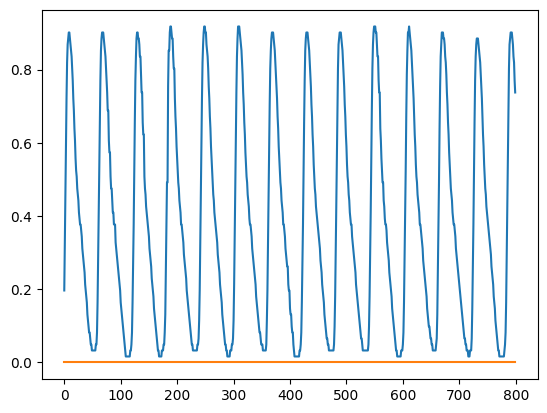

In [3]:
#Import_data
dataset = PPGDataset('D:\ppg_project\Data\data_train',label_list = {"Case":["PAC","PVC","PAC-nhip-doi","PAC-cap-doi","PVC-nhip-doi","PVC-cap-doi"],"Group": True})
print(dataset.count)

print(dataset[111][0].shape)
for i in [22]:
    plt.plot(dataset[i][0].numpy().flatten())
    plt.plot(dataset[i][1].numpy().flatten())

# plt.plot(dataset[0][1].numpy())
    plt.show()

Training

In [4]:
import torch.nn.functional as F

if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

para = {    "Number class":             1,
			"Serie length":         800, #The length of the 1D data
            "Input size": 1,
            "Filter nums":          [32,64,128,256], #The number of filters for each multiresblocks of one side of the model (1xn) 
            "Block kernel":         [3,5,7], #The kernel size of each multiresblocks (1x3)
			"Pooling kernel":       [2,2,2,2], #The kernel size of each pooling layer (1xn)
			"Transpose kernel":     [2,2,2,2],
            "Respath length": 4
    }

def loss(predict, truth):
    truth = truth.to(torch.int64)  # Ensure labels are int64 for PyTorch compatibility
    log_prob = F.log_softmax(predict, dim=1)  # Compute log-softmax
    loss = -log_prob.gather(dim=1, index=truth.unsqueeze(1)).squeeze(1)  # Gather log probabilities of the correct classes
    return loss.mean()

model = MultiResUnet(para = para, alpha = 1.67).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
builder = k_fold_training(dataset,5, criterion = nn.L1Loss())
builder.training(model,device,optimizer,num_epochs=300,batch=64,visualize=1)

Fold : 1
Train and validate dataset are overlap:  False
Iteration: 1/300. loss_train: 0.33445796370506287. loss_val: 0.06068176031112671
Iteration: 2/300. loss_train: 0.1589224934577942. loss_val: 0.06799597293138504
Iteration: 3/300. loss_train: 0.13292309641838074. loss_val: 0.06424165517091751
Iteration: 4/300. loss_train: 0.10606759786605835. loss_val: 0.06804297119379044
Iteration: 5/300. loss_train: 0.09586731344461441. loss_val: 0.06777895241975784
Iteration: 6/300. loss_train: 0.0834357813000679. loss_val: 0.06964951008558273
Iteration: 7/300. loss_train: 0.07912977039813995. loss_val: 0.08097478747367859
Iteration: 8/300. loss_train: 0.08063336461782455. loss_val: 0.0775284618139267
Iteration: 9/300. loss_train: 0.07250586152076721. loss_val: 0.0604715496301651
Iteration: 10/300. loss_train: 0.06969314813613892. loss_val: 0.06578698009252548
Iteration: 11/300. loss_train: 0.058107297867536545. loss_val: 0.07117874175310135
Iteration: 12/300. loss_train: 0.057507455348968506. l

Performance

Max loss:  1.0003986
Mean loss:  0.2770297
Min loss:  0.00039030405
Number of test:  84


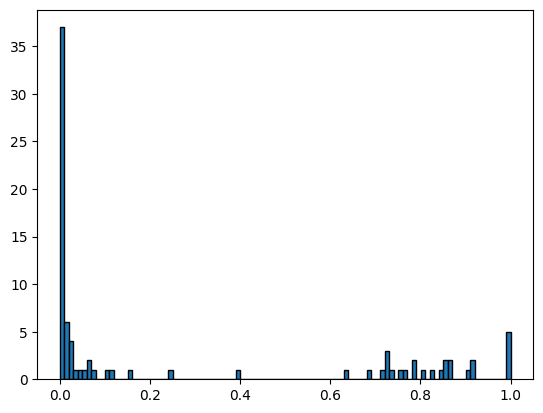

0.15762453


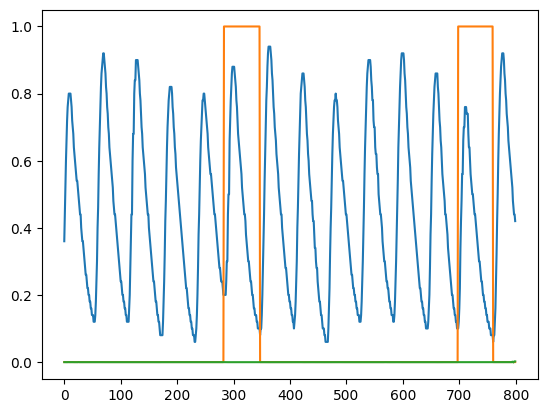

0.8502612


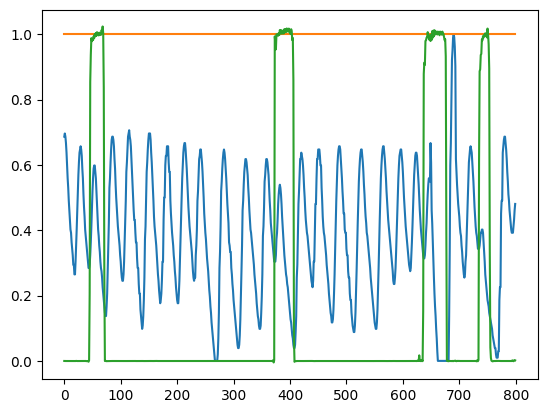

0.9057527


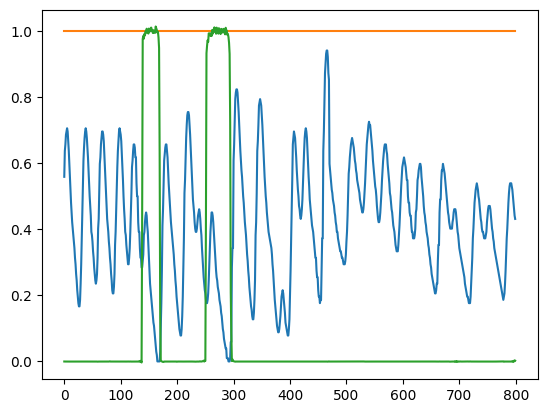

1.6617254e-07


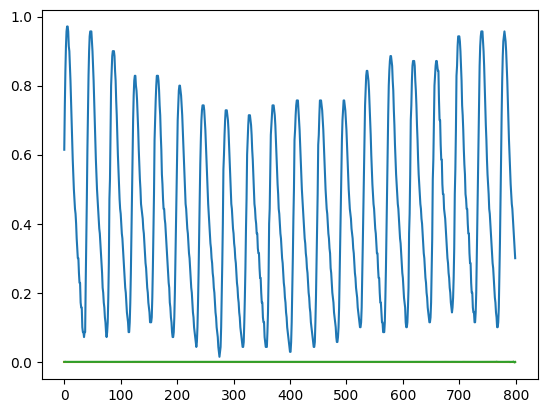

1.7769001e-07


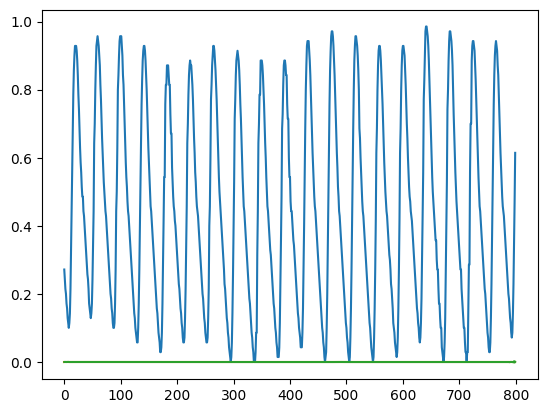

1.6956542e-07


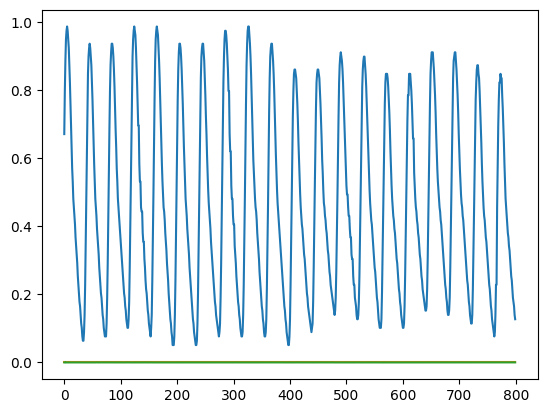

1.7377559e-07


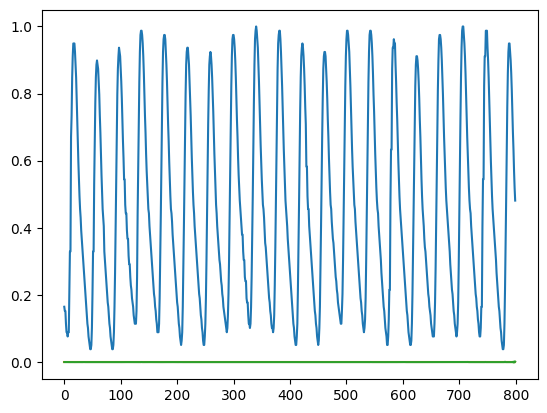

2.2919757e-07


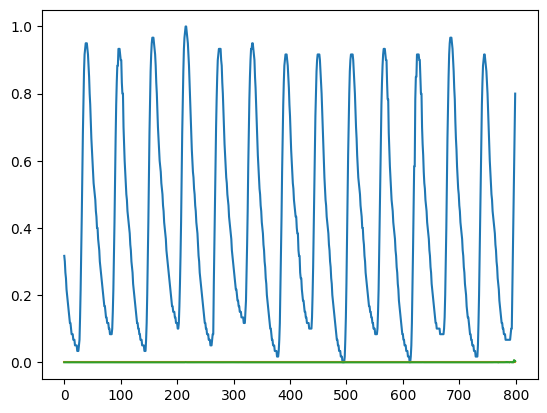

1.7155288e-07


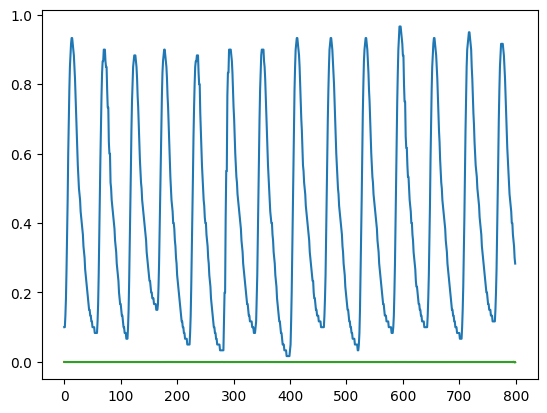

1.7187773e-07


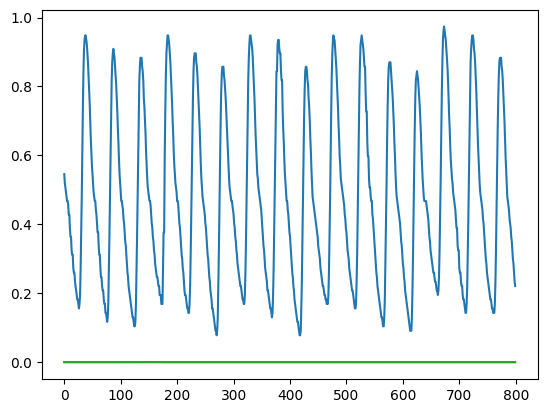

1.6663398e-07


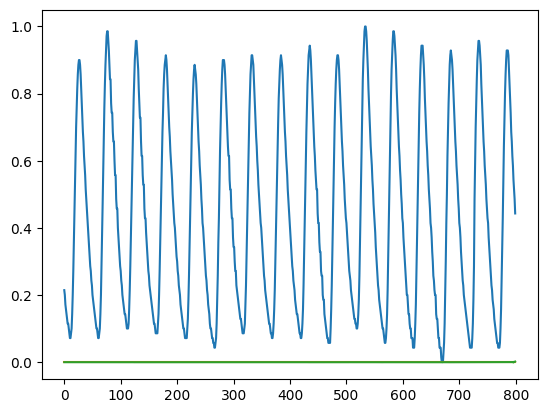

1.6761638e-07


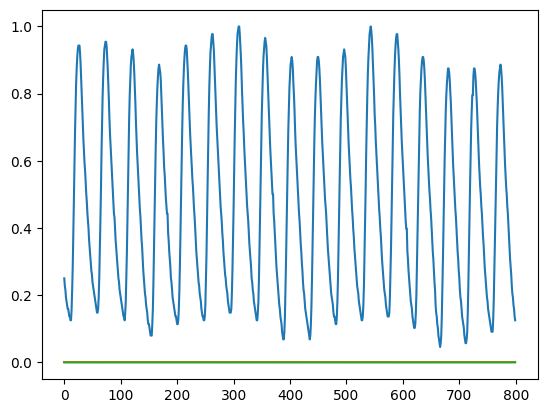

0.010766724


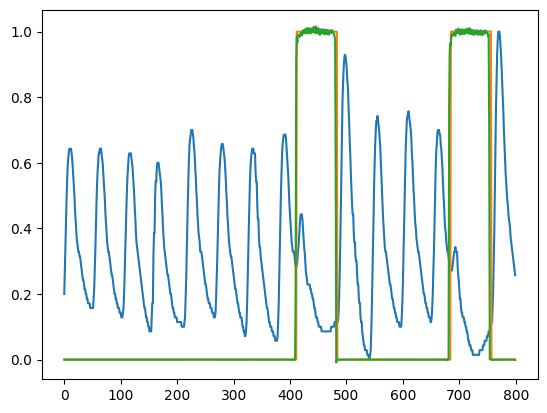

0.07886978


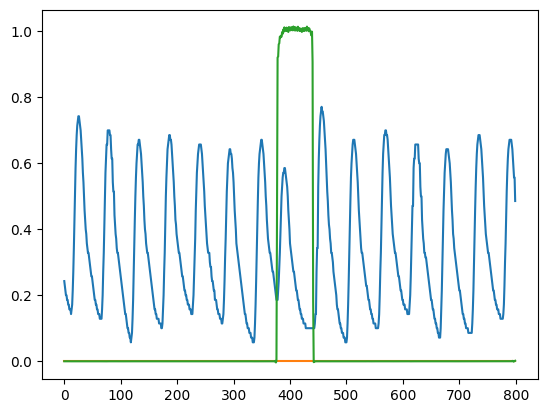

0.0030590568


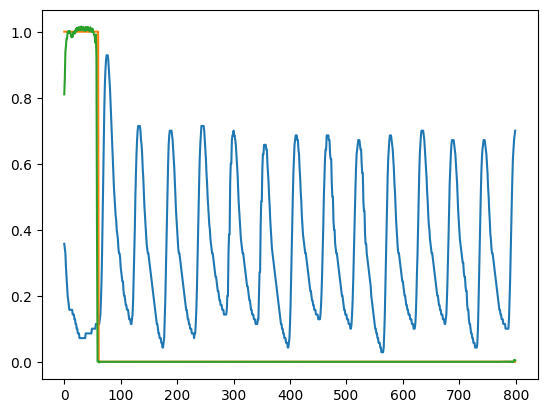

1.5570828e-07


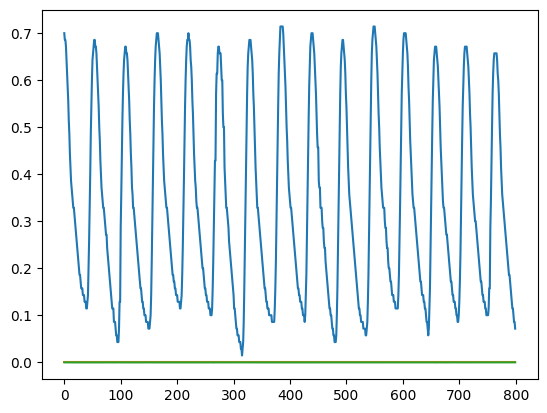

0.8475918


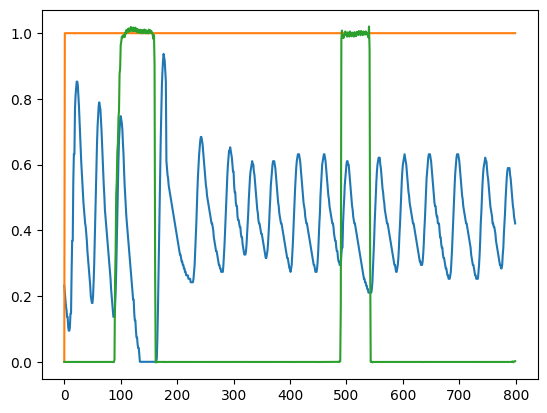

1.0007842


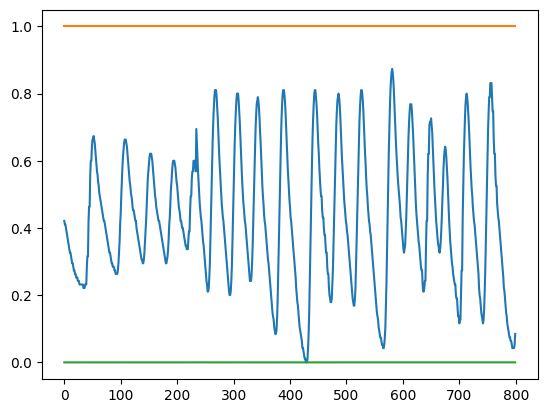

0.75458014


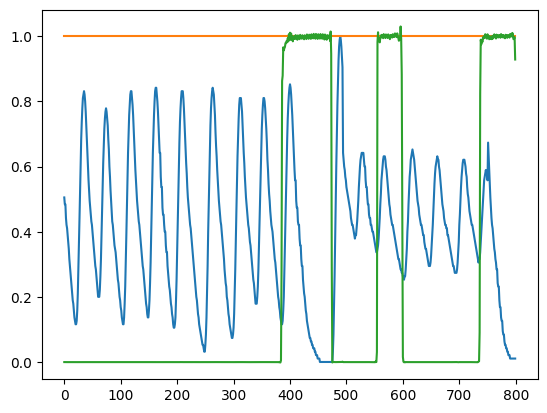

0.78423214


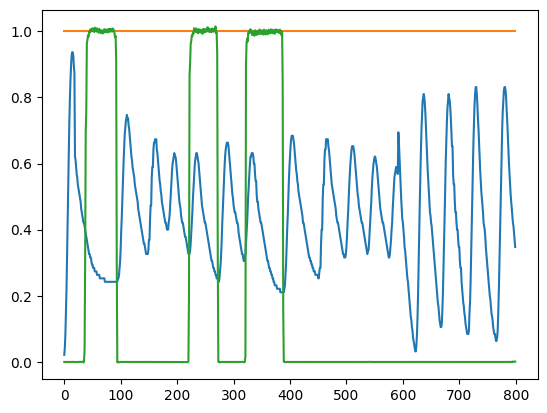

0.8653029


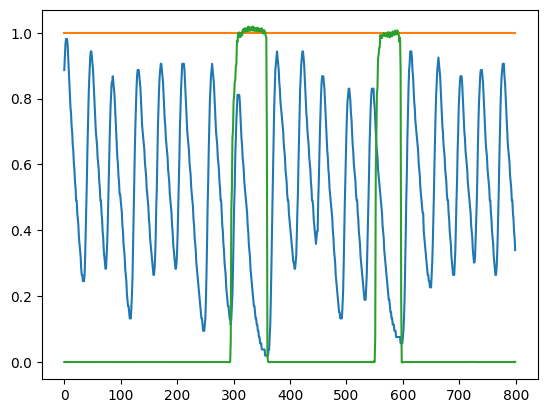

1.6548503e-07


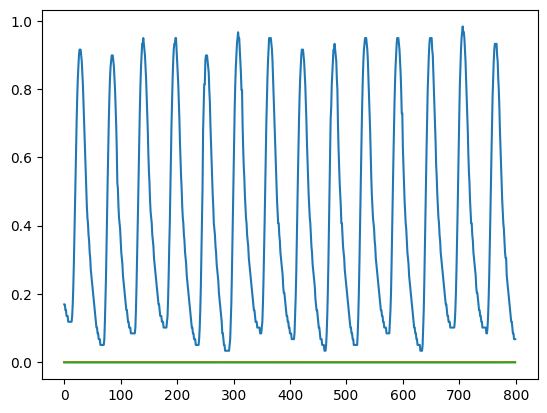

1.6550909e-07


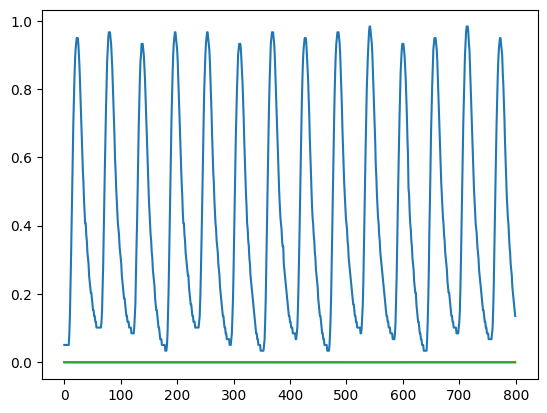

1.7454833e-07


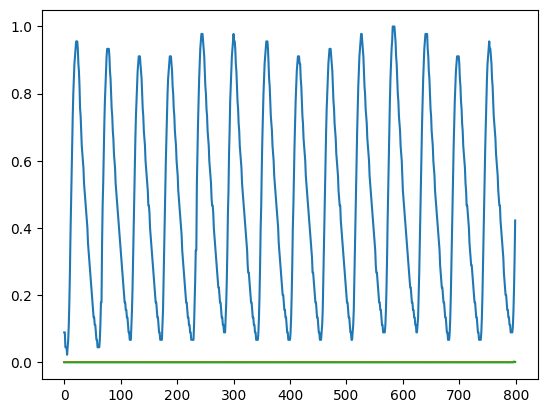

1.7733083e-07


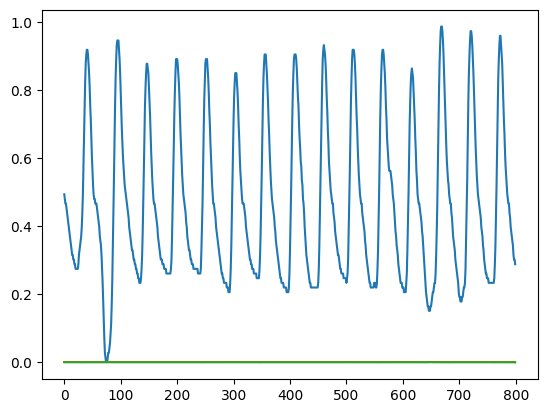

1.9572144e-07


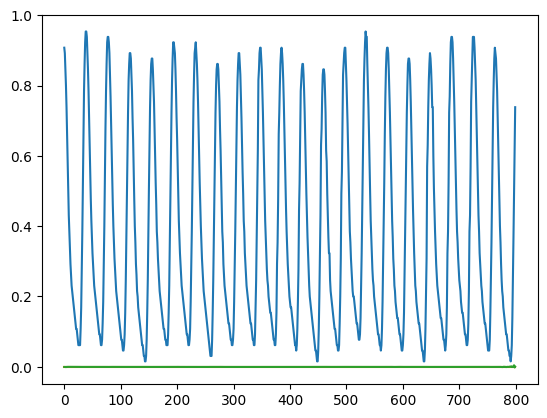

0.9118675


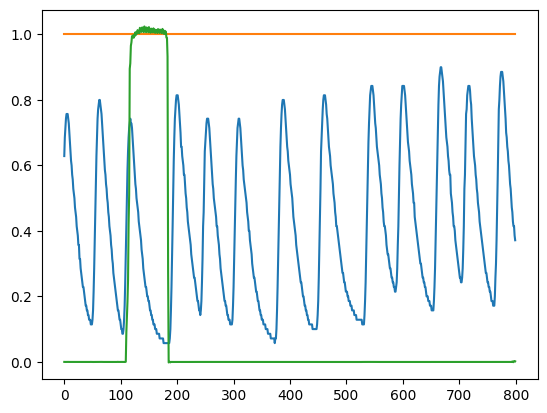

1.9258226e-07


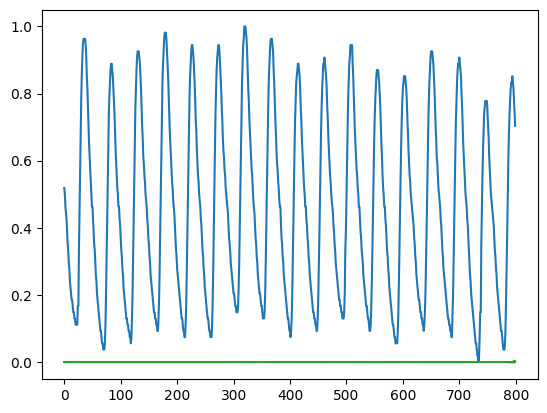

1.9426159e-07


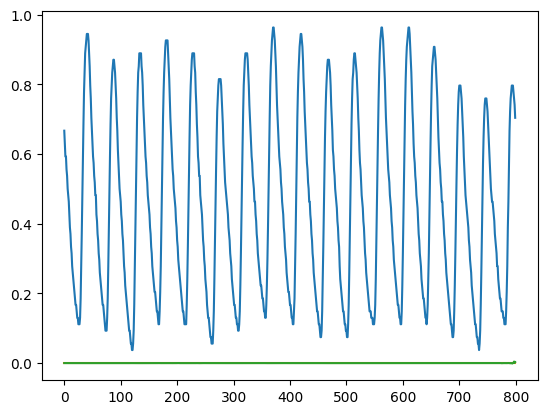

0.7630183


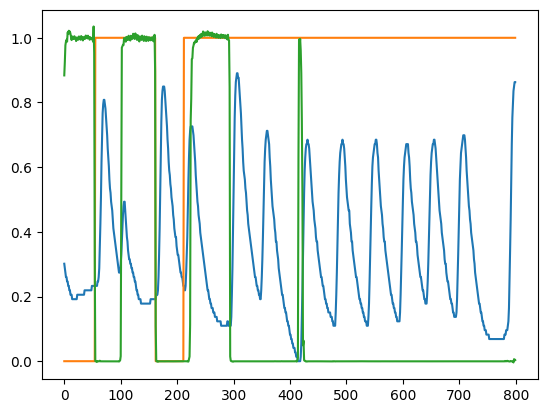

1.658869e-07


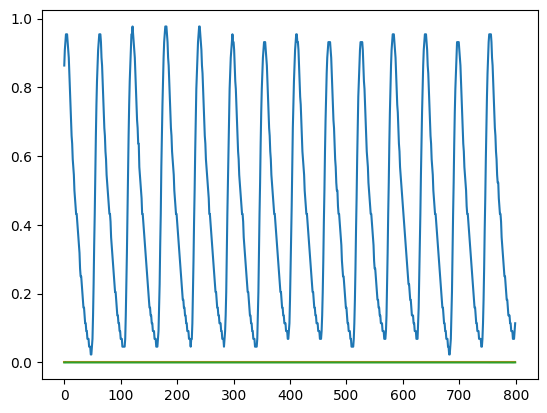

2.147203e-07


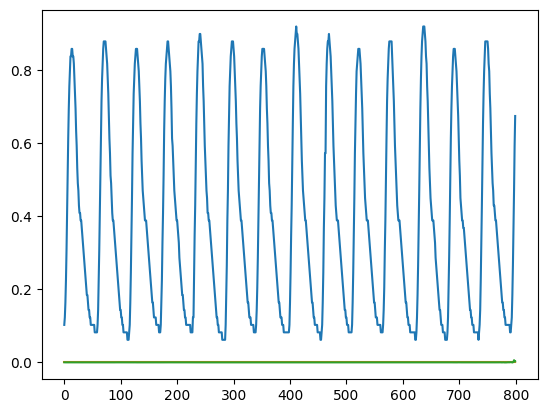

1.7782884e-07


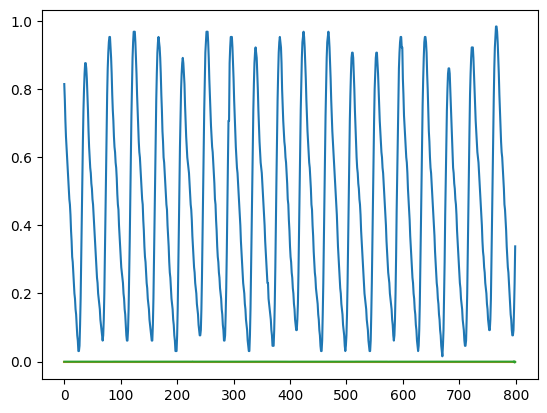

1.7096194e-07


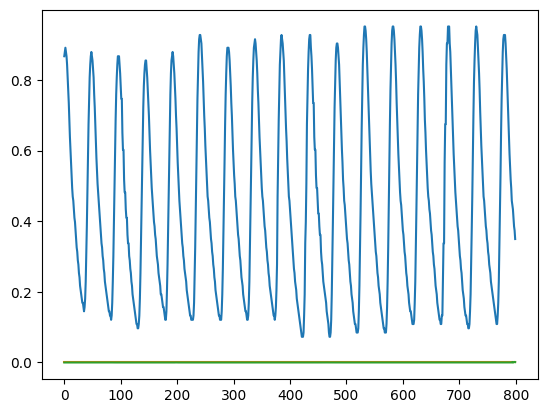

1.7065214e-07


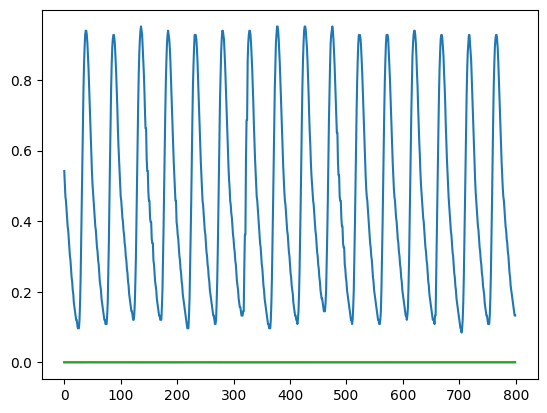

1.7218018e-07


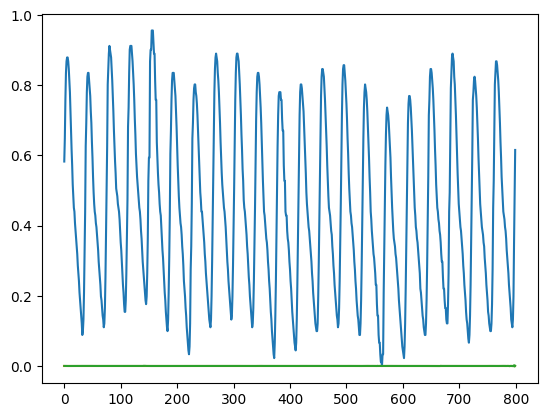

1.5537593e-07


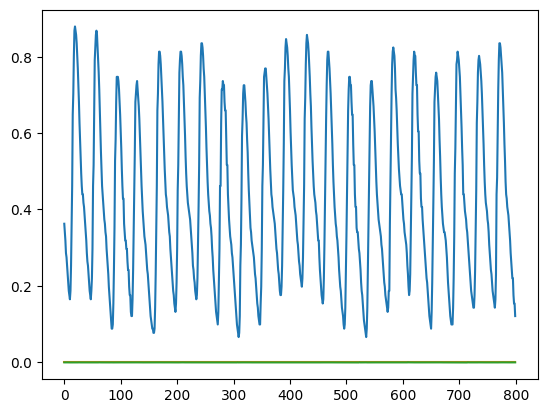

1.6414447e-07


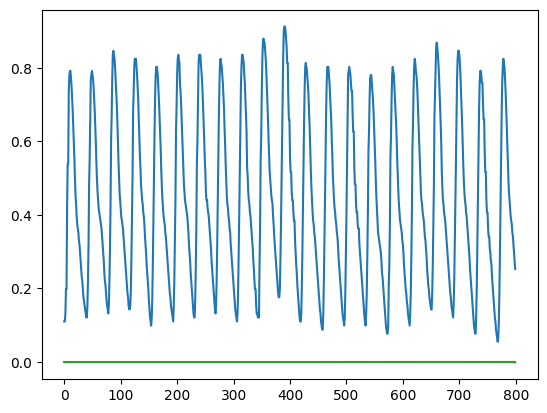

3.192124e-07


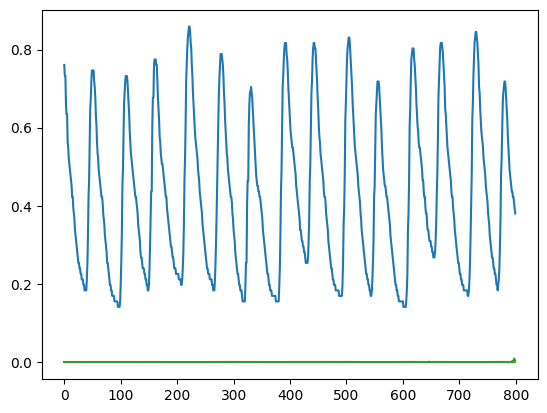

0.72285014


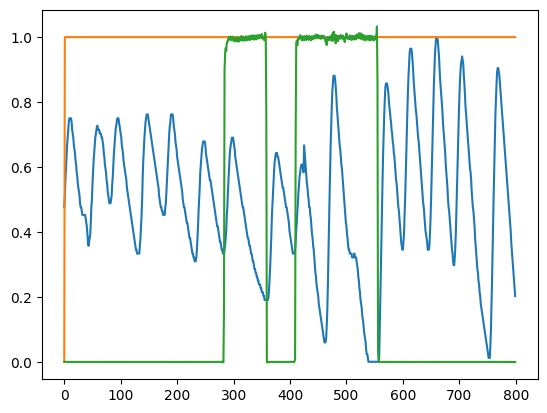

1.6630071e-07


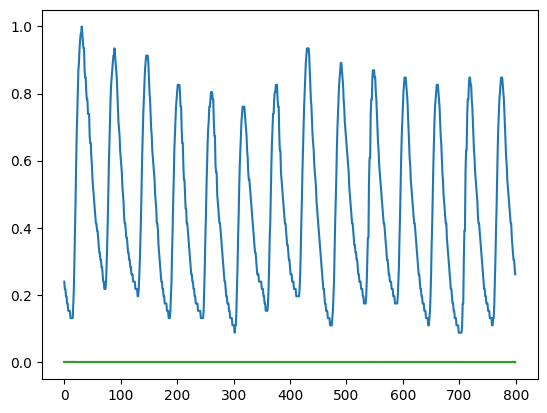

0.8417392


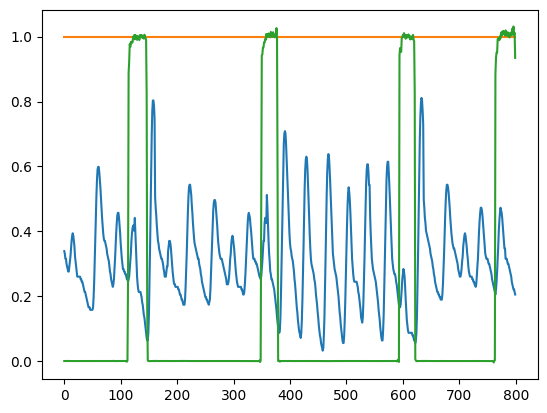

0.91216254


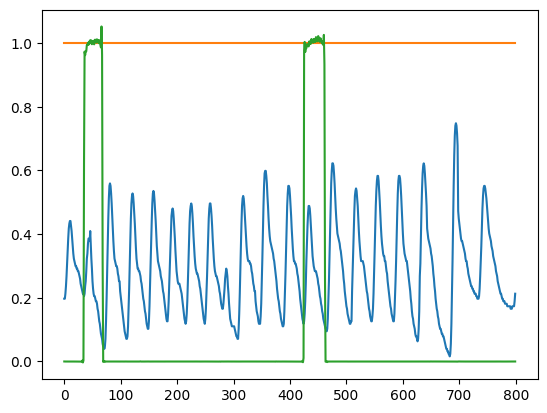

2.6147555e-07


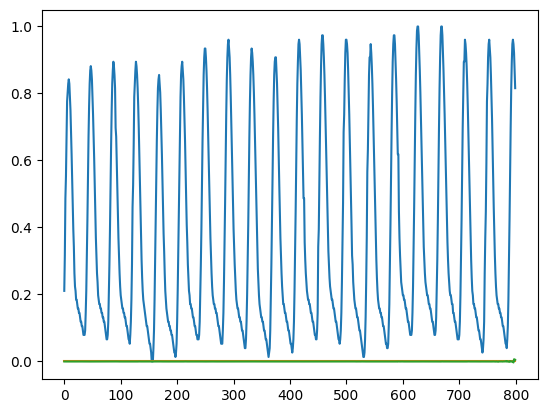

0.0017452505


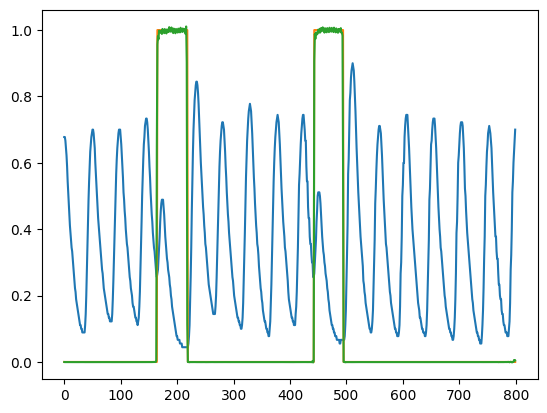

0.0243403


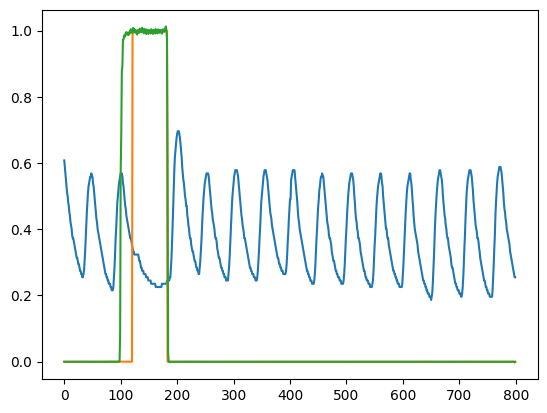

0.008822142


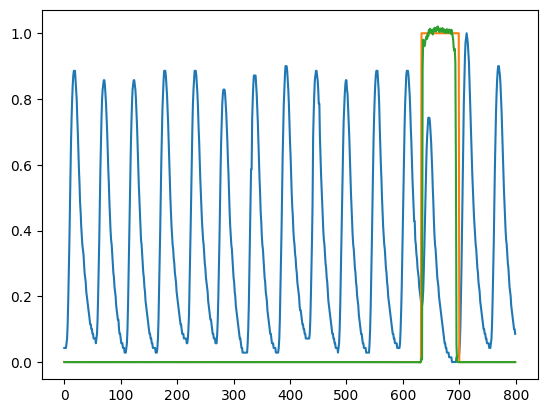

0.6282797


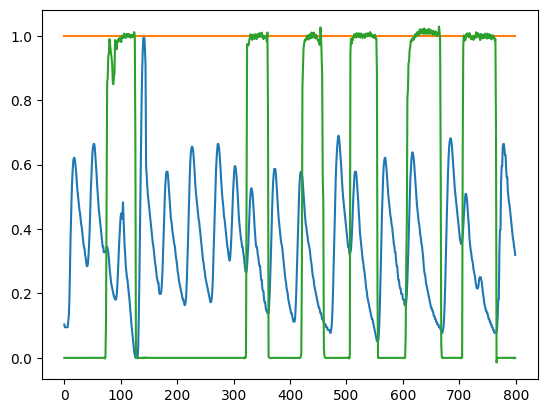

0.70754194


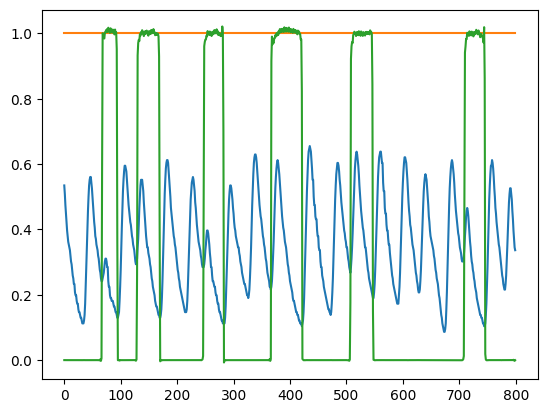

0.042524233


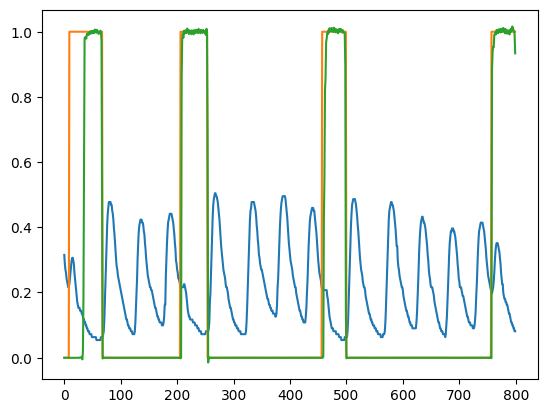

0.030358972


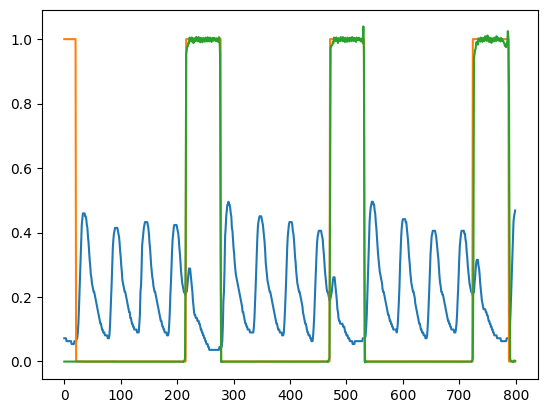

0.102939785


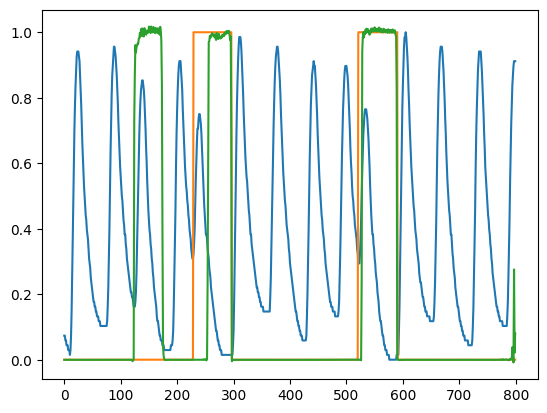

1.6403966e-07


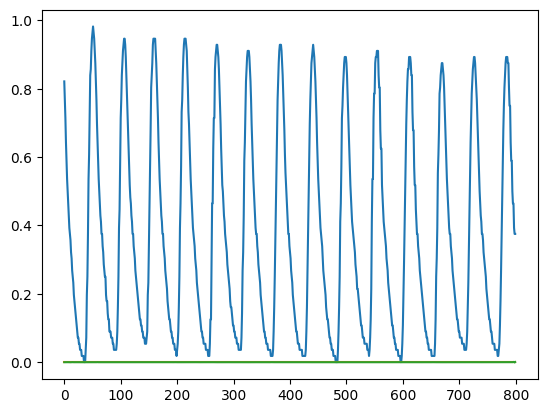

1.9528551e-07


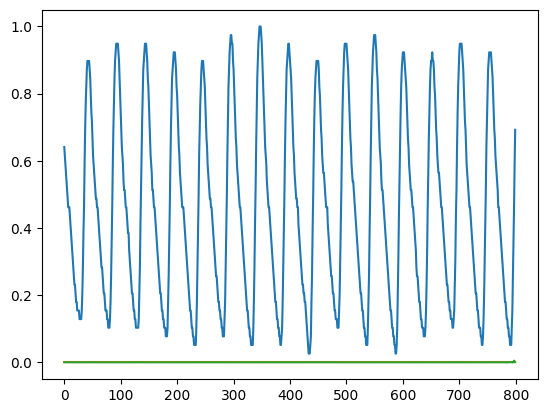

1.7247605e-07


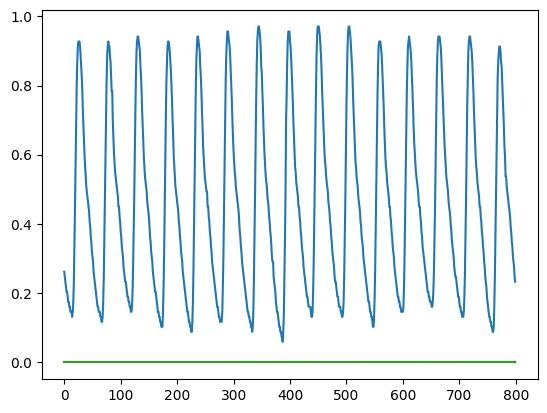

0.6744875


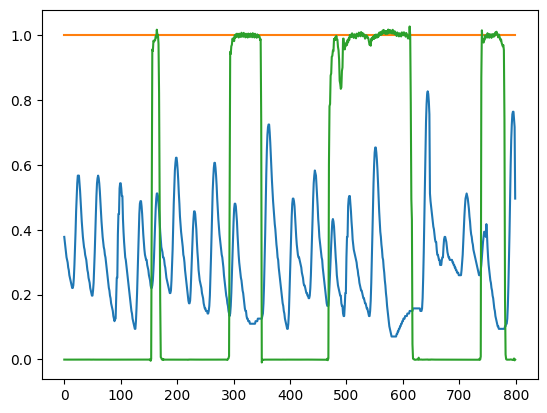

0.7234887


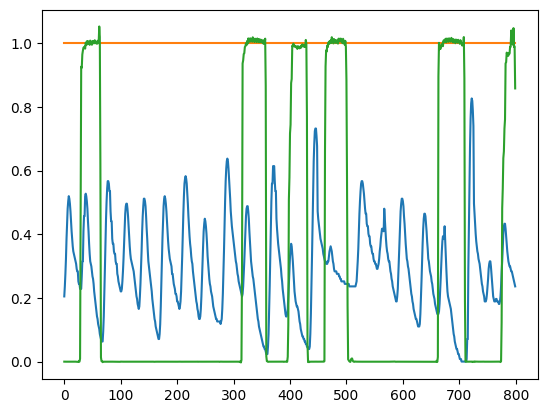

0.0057428996


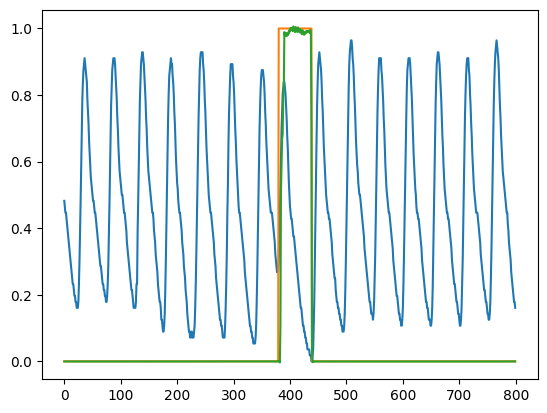

1.0007776


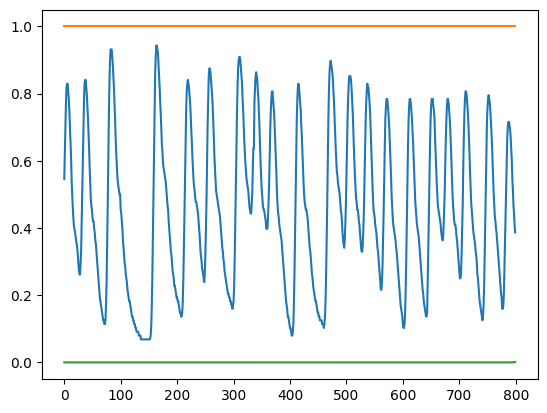

0.7801428


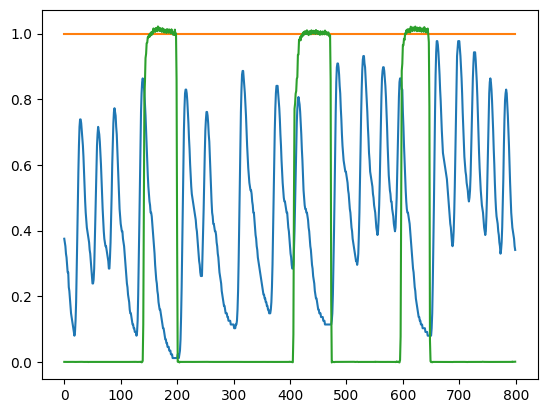

1.0007678


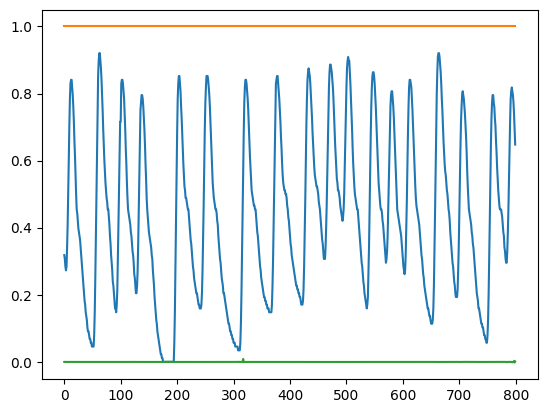

0.016824557


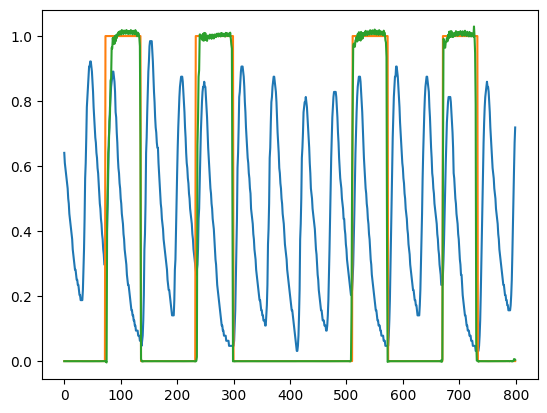

0.38862577


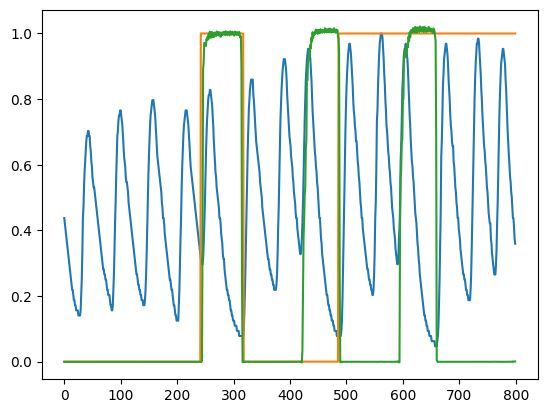

0.017285451


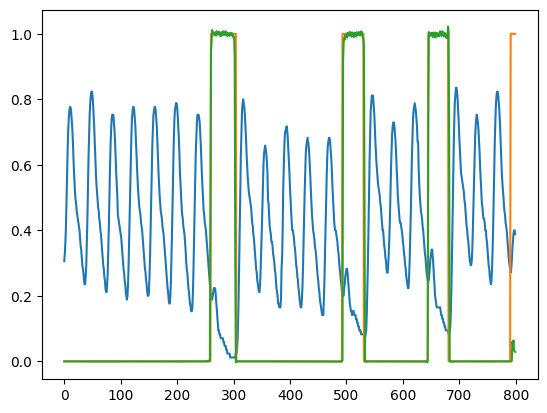

0.04994664


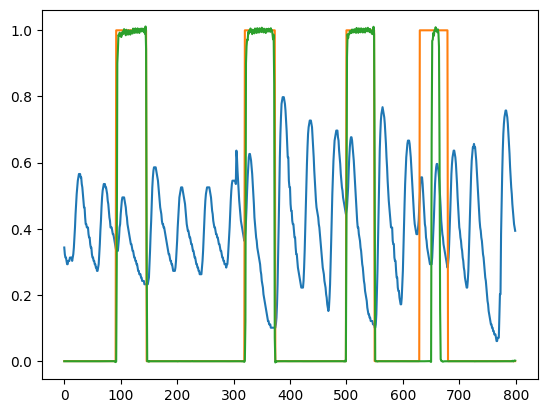

2.1665048e-07


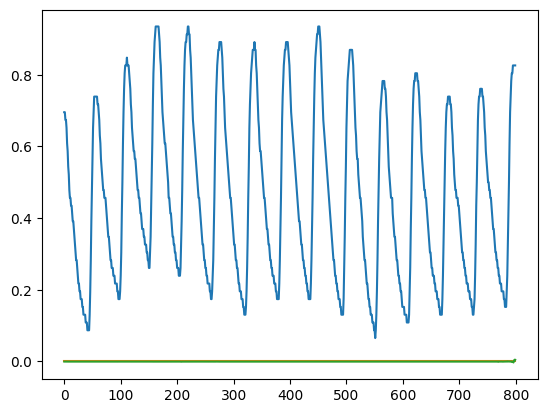

0.71216077


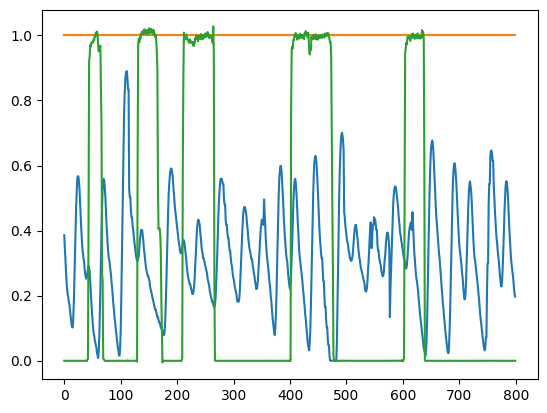

0.06660263


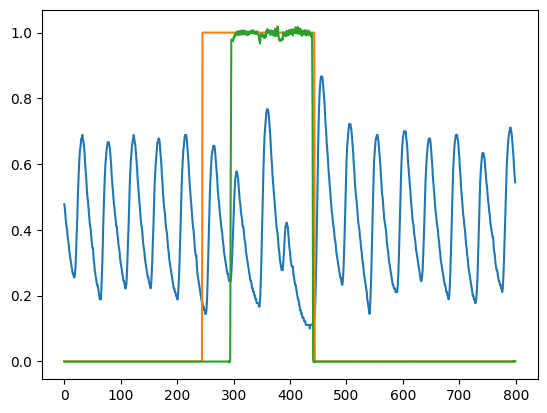

0.24296485


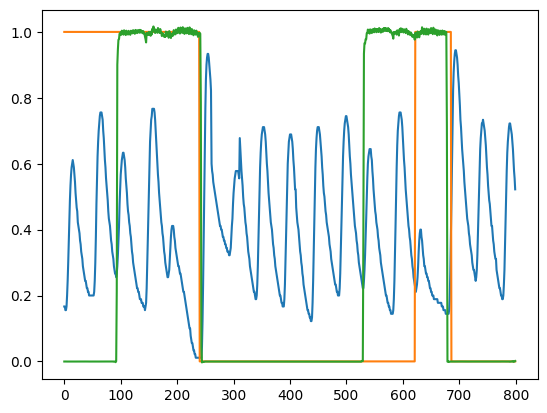

0.0073921033


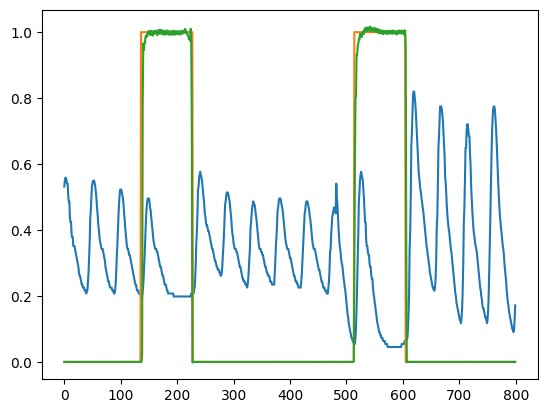

0.010272561


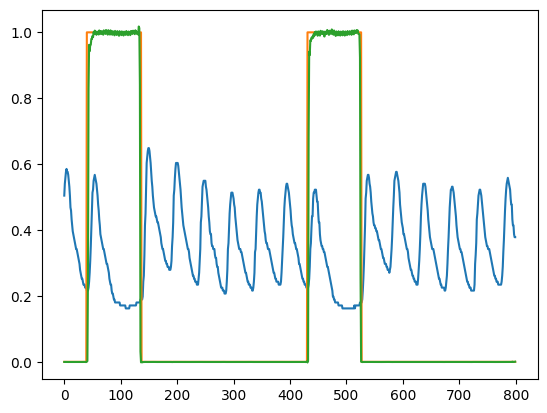

0.009258667


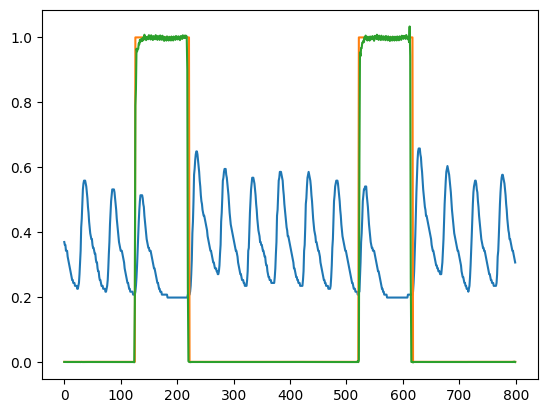

0.004187957


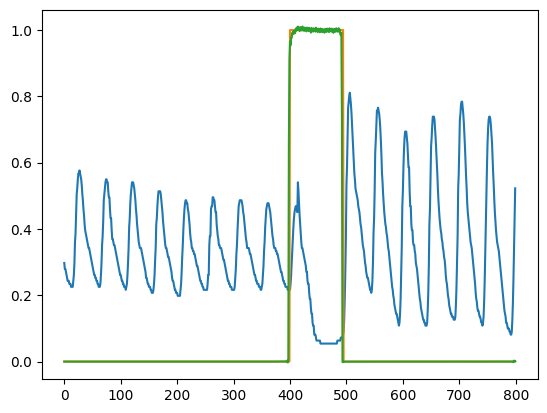

0.021456536


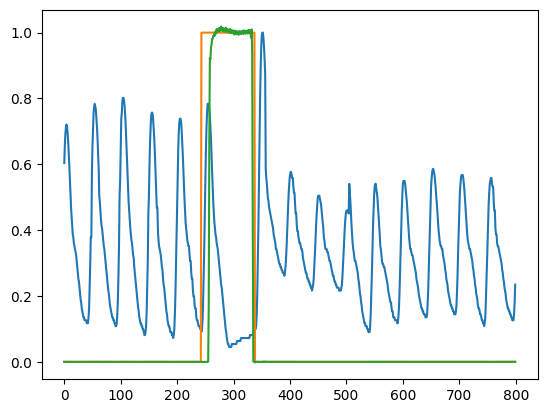

0.79285854


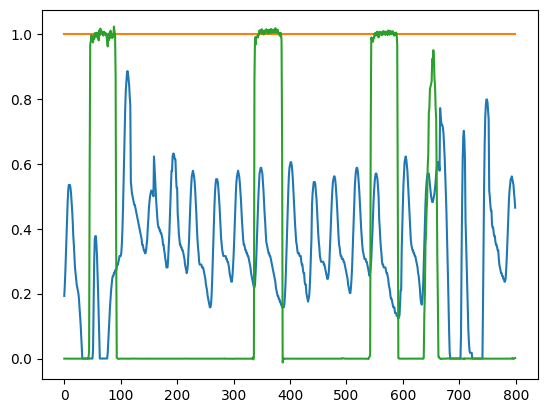

0.7116549


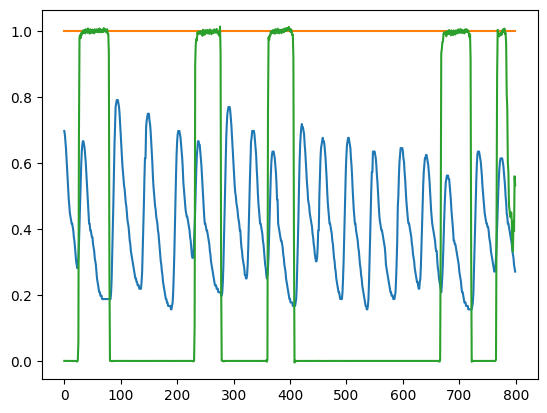

0.8604837


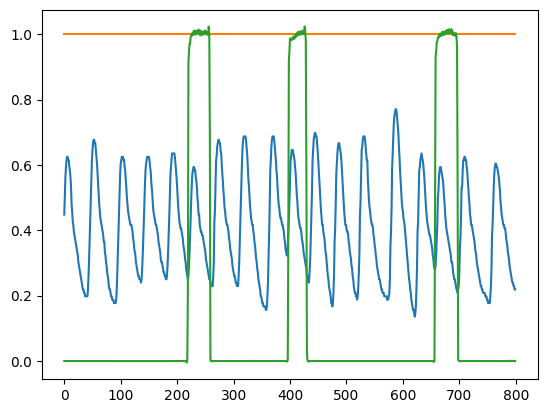

1.0007521


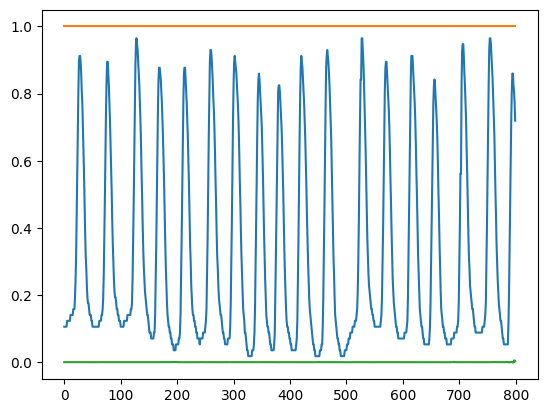

0.052596815


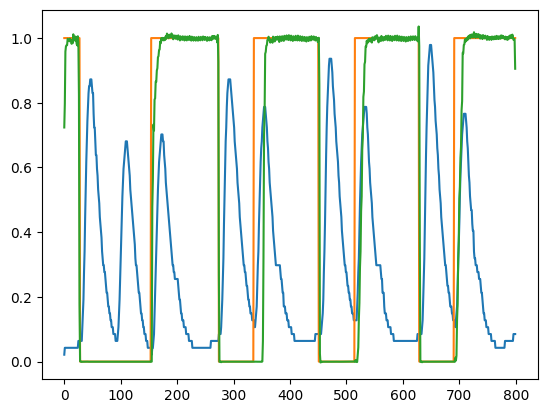

0.11073322


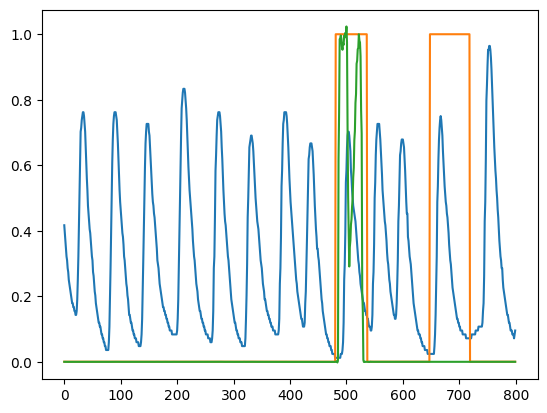

0.8205897


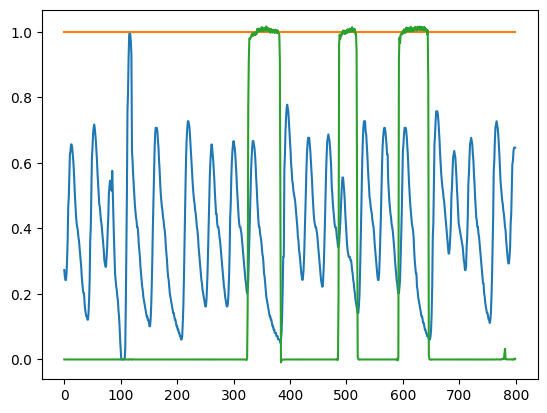

1.0007976


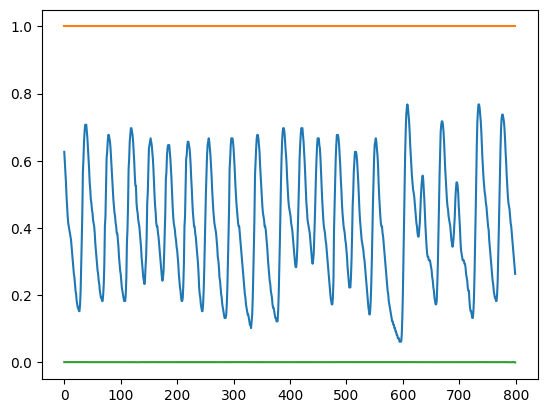

0.0050281687


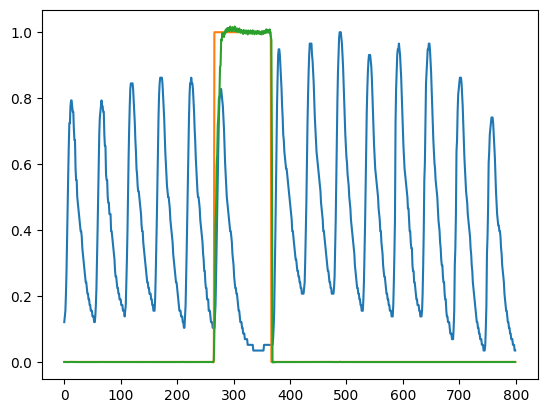

0.01606839


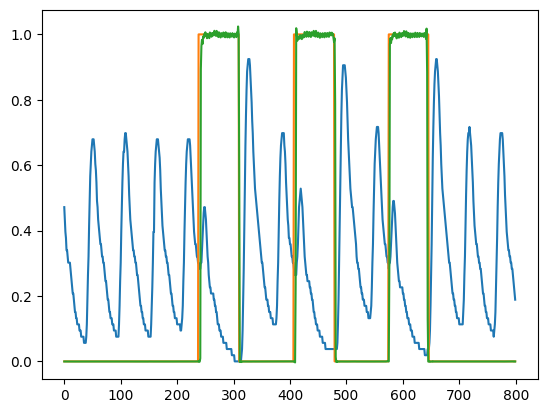

In [5]:
shower = performance()
test_data = PPGDataset('D:\ppg_project\Data\data_test',label_list = "AR")
shower.test(model,device,test_data,per_fnc = "series")
criterion = nn.MSELoss()
for i in range(len(test_data)):
    output = torch.stack([test_data[i][1]]).to(device)
    input = torch.stack([test_data[i][0]]).to(device)
    y_hat = model.forward(input)
    loss = criterion(y_hat,output)
    # if loss.cpu().detach().numpy()<0.3:
    print(loss.cpu().detach().numpy())
    plt.plot(input.cpu().detach().numpy().flatten()[0:1000])
    plt.plot(output.cpu().detach().numpy().flatten()[0:1000])
    plt.plot(y_hat.cpu().detach().numpy().flatten()[0:1000])
    plt.show()

In [ ]:
import matplotlib.pyplot as plt
import torch
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
from sklearn.metrics import mean_absolute_error, mean_squared_error
from ppg_labeled_load import PPGDataset # Import dataset

# --- 1. LOAD TEST DATA (Tránh lỗi NameError) ---
# Đảm bảo đường dẫn đúng
try:
    test_data = PPGDataset(r'D:\ppg_project\Data\data_test', label_list="AR")
    print(f"Loaded Test Data: {len(test_data)} samples")
except Exception as e:
    print(f"Error loading data: {e}")
    # Tạo dummy data nếu lỗi để code không crash
    test_data = [] 

# --- SNR CALCULATION FUNCTION ---
def calculate_snr(y_true, y_pred):
    noise = y_true - y_pred
    signal_power = np.sum(y_true ** 2)
    noise_power = np.sum(noise ** 2)
    if noise_power == 0:
        return 100.0
    return 10 * np.log10(signal_power / noise_power)

# --- CONFIGURATION ---
num_samples = 100
cols = 2
rows = 50 
limit_points = 1000 

# Lists to store statistical results
stats_data = []

# Create a large figure
fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows)) 
fig.suptitle(f"Comparison and Statistics of {num_samples} Samples", fontsize=16, y=1.002)
axes = axes.flatten()

criterion = nn.L1Loss()
model.eval()

print(f"Processing and plotting {num_samples} samples...")

with torch.no_grad():
    for i in range(num_samples):
        ax = axes[i]
        
        if i < len(test_data):
            # 1. Get Data & Forward Pass
            output = torch.stack([test_data[i][1]]).to(device)
            input_sig = torch.stack([test_data[i][0]]).to(device)
            
            y_hat = model(input_sig)
            
            # 2. Calculate Loss
            loss_val = criterion(y_hat, output).item()
            
            # 3. Convert to Numpy & Flatten
            np_in = input_sig.cpu().detach().numpy().flatten()[:limit_points]
            np_out = output.cpu().detach().numpy().flatten()[:limit_points]
            np_pred = y_hat.cpu().detach().numpy().flatten()[:limit_points]
            
            # 4. Calculate Statistics
            mae = mean_absolute_error(np_out, np_pred)
            rmse = np.sqrt(mean_squared_error(np_out, np_pred))
            pearson, _ = pearsonr(np_out, np_pred)
            snr = calculate_snr(np_out, np_pred)
            
            stats_data.append({
                "Sample": i, "MAE": mae, "RMSE": rmse, "Pearson": pearson, "SNR (dB)": snr
            })
            
            # 5. PLOTTING
            # Input (Noisy) -> BLUE (Xanh dương)
            ax.plot(np_in, label='Input', color='blue', alpha=0.4, linewidth=1)
            
            # Output (Ground Truth) -> ORANGE
            ax.plot(np_out, label='Output', color='orange', alpha=0.8, linewidth=1.5)
            
            # Prediction (y_hat) -> GREEN (Solid line)
            ax.plot(np_pred, label='Prediction', color='green', linestyle='-', linewidth=1.5)
            
            ax.set_title(f"Sample {i} | L1 Loss: {loss_val:.4f} | Pearson: {pearson:.4f}", fontsize=9)
            
            if i == 0: ax.legend(loc='upper right') 
            
        else:
            ax.axis('off')

plt.tight_layout()
plt.show()

model.train() 

# --- DISPLAY STATISTICS ---
print("\n" + "="*30 + " STATISTICAL RESULTS TABLE " + "="*30)
df_stats = pd.DataFrame(stats_data)
mean_metrics = df_stats[["MAE", "RMSE", "Pearson", "SNR (dB)"]].mean()
df_stats.loc['AVERAGE'] = mean_metrics
df_stats.loc['AVERAGE', 'Sample'] = '---' 

try:
    from IPython.display import display
    display(df_stats)
except:
    print(df_stats)

print("\n" + "-"*20 + " SUMMARY " + "-"*20)
print(f"Average MAE:     {mean_metrics['MAE']:.5f}")
print(f"Average RMSE:    {mean_metrics['RMSE']:.5f}")
print(f"Average Pearson: {mean_metrics['Pearson']:.5f}")
print(f"Average SNR:     {mean_metrics['SNR (dB)']:.2f} dB")